In [52]:
# Required Libraries 

%pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels jupyter==1.0.0 notebook==7.2.0 ipykernel==6.29.4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler # Data preprocessing
from sklearn.model_selection import train_test_split # Data splitting
from sklearn.linear_model import LinearRegression # Machine learning model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Model evaluation metrics Validation


In [54]:
# Model -> prediction is not an accurate data
# need to fnd the accurate value like 95%, 85% 

In [55]:
df = pd.read_csv('house_price_data.csv')
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            100 non-null    int64  
 1   Bedrooms             100 non-null    int64  
 2   Bathrooms            100 non-null    int64  
 3   Age_years            100 non-null    int64  
 4   Distance_to_city_km  97 non-null     float64
 5   Garage               100 non-null    int64  
 6   Floors               100 non-null    int64  
 7   Price_USD            100 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 6.4 KB


In [57]:
# Before any data prediction, need to verify whether there is NULL values running the code - df.info()

df.fillna(df.mean(), inplace=True)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.100000,1,3,446385
1,4107,4,2,17,23.300000,1,3,489543
2,1460,2,3,17,7.300000,0,1,185140
3,1894,2,3,1,14.676289,1,1,286522
4,1730,4,2,34,3.500000,0,2,212784
...,...,...,...,...,...,...,...,...
95,4443,3,3,21,29.700000,0,2,495608
96,4493,3,2,21,13.000000,0,2,556496
97,2100,1,1,5,11.800000,1,2,277020
98,1302,5,3,14,23.500000,1,3,199575


In [58]:
# Describe - find the highest range, lowest range 

df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2717.380000,2.980000,2.040000,21.440000,14.676289,0.420000,1.890000,328377.300000
std,1104.021197,1.476961,0.839913,11.001671,8.387289,0.496045,0.827495,134402.974694
min,621.000000,1.000000,1.000000,0.000000,1.400000,0.000000,1.000000,55418.000000
25%,1807.250000,1.750000,1.000000,14.000000,7.150000,0.000000,1.000000,210127.250000
50%,2791.500000,3.000000,2.000000,22.500000,14.688144,0.000000,2.000000,332383.500000
75%,3622.000000,4.000000,3.000000,31.000000,21.250000,1.000000,3.000000,439099.250000
max,4493.000000,5.000000,3.000000,39.000000,29.700000,1.000000,3.000000,578851.000000


In [59]:
# Finding how many null values

df.isnull().sum()


Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    0
Garage                 0
Floors                 0
Price_USD              0
dtype: int64

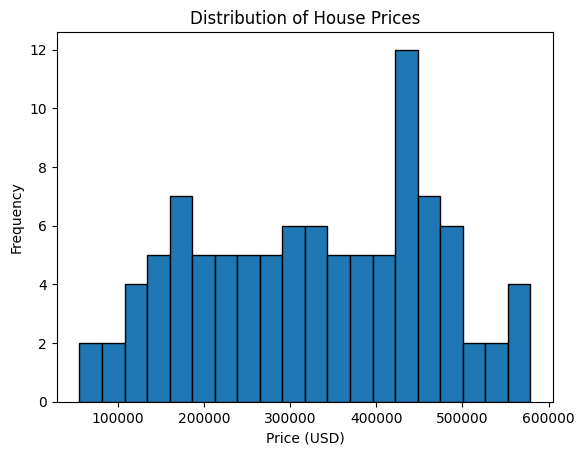

In [60]:
# Visualization the data with Matplotlib

plt.Figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, edgecolor='k')
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

In [61]:
# Going to split the data, Finding the input features and output features 
# updating the i/p and o/p 

features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_city_km', 'Garage', 'Floors']
X = df[features]
y = df['Price_USD']



In [62]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=65)


In [63]:
X.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
0,3774,2,3,28,16.100000,1,3
1,4107,4,2,17,23.300000,1,3
2,1460,2,3,17,7.300000,0,1
3,1894,2,3,1,14.676289,1,1
4,1730,4,2,34,3.500000,0,2


In [64]:
y.head()

0    446385
1    489543
2    185140
3    286522
4    212784
Name: Price_USD, dtype: int64

In [65]:
X_train.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
67,1200,5,2,16,14.3,0,2
13,2082,4,3,7,24.1,0,3
77,2739,5,2,12,3.7,1,3
66,3035,3,1,25,19.7,0,2
25,4085,3,1,26,16.9,0,3


In [66]:
X_test.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
37,3504,1,1,16,1.4,1,2
81,4099,4,1,0,25.5,1,1
39,1074,2,2,29,2.3,1,1
61,1246,4,3,21,1.8,1,2
76,1963,1,1,23,1.5,0,2


In [67]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
X_test

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
37,3504,1,1,16,1.4,1,2
81,4099,4,1,0,25.5,1,1
39,1074,2,2,29,2.3,1,1
61,1246,4,3,21,1.8,1,2
76,1963,1,1,23,1.5,0,2
90,3673,3,1,1,24.3,0,3
27,3033,1,3,33,20.1,0,3
86,3752,1,3,22,21.2,1,3
28,1815,3,2,20,9.1,1,1
69,2661,5,3,32,28.3,0,2


In [69]:
y_pred = model.predict(X_test)
print(y_pred)

[445488.95882889 516833.18697792 137569.90319901 228837.73644688
 227492.04570845 454452.50152156 304534.67569219 430762.19111588
 241845.22376716 287410.6863168  393386.72774084 396296.72336126
 215776.72815442 172569.83449455 299320.44715584 153252.86119252
 409446.07561413 294777.44251115 468457.63248631 399944.24965713]


In [70]:
# Actual Data
print(y_test)

37    446271
81    495377
39    167459
61    258117
76    183142
90    444156
27    304828
86    435270
28    262241
69    298479
72    373374
35    413356
31    244621
91    179051
43    343611
52    155100
14    421983
87    278495
51    468519
41    396888
Name: Price_USD, dtype: int64


In [71]:
# Identifiying the predicted value is coorect accurately 

mae = mean_absolute_error(y_test, y_pred)
print(mae)

16139.523814559903


In [72]:
# Trying to understand 

rmse = mean_squared_error(y_test, y_pred)
print(rmse)

440284330.3786682


In [73]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

20982.95332832507


In [74]:
# Finding how much accuracy 

r2 = r2_score(y_test, y_pred)
print(r2)

0.9615078027210272


In [75]:
# Going to predict the price based on the model which is not avaiable on the excel sheet
# Going to predict the new house the price 

new_houses = pd.DataFrame({
    'Area_sqft'           : [1500, 3000],
    'Bedrooms'            : [2,    4   ],
    'Bathrooms'           : [1,    3   ],
    'Age_years'           : [10,   5   ],
    'Distance_to_city_km' : [15,   8   ],
    'Garage'              : [0,    1   ],
    'Floors'              : [1,    2   ]
})

In [76]:
new_houses

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
0,1500,2,1,10,15,0,1
1,3000,4,3,5,8,1,2


In [77]:
predictions = model.predict(new_houses)
print(predictions)

[168220.06350639 457817.05041187]


In [78]:
print(model.intercept_)

9972.65692918637


In [79]:
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})

In [80]:
print(coef_df)

               Feature   Coefficient
0            Area_sqft    119.064384
1             Bedrooms  14812.637102
2            Bathrooms  10587.169449
3            Age_years  -2439.463639
4  Distance_to_city_km  -3046.940808
5               Garage  17137.758509
6               Floors   9537.136109
